Importando as bibliotecas e módulos necessários: 

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

Importando as bases necessárias: 

In [4]:
df_2019 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\Features_2019.parquet", engine="pyarrow")
df_2021 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\Features_2021.parquet", engine="pyarrow")
df_2023 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\Features_2023.parquet", engine="pyarrow")

### Modelagem Preditiva 
Esse código implementa modelo de Árvore de Decisão para prever se um aluno será Insuficiente ou Proficiente.

#### Árvore de Decisão com Balanceamento dos Dados de treino utilizando 'SMOTE' 
O balanceamento dos dados ocorre quando há uma classe dominante, como, por exemplo, muitos "Insuficientes" e poucos "Proficientes" e o modelo aprende a prever apenas a classe majoritária. O que o SMOTE faz é a criação de exemplos sintéticos da classe minoritária para equilibrar as quantidades entre os elementos das classes.

#### 2019

Distribuição antes do SMOTE:
PROFICIENCIA_DESCRICAO
0    1239902
1     289642
Name: count, dtype: int64

Distribuição após SMOTE:
PROFICIENCIA_DESCRICAO
0    1239902
1    1239902
Name: count, dtype: int64

Acurácia:
0.5967488434491758

Classification Report:
              precision    recall  f1-score   support

Insuficiente       0.90      0.57      0.69    309976
 Proficiente       0.28      0.73      0.41     72411

    accuracy                           0.60    382387
   macro avg       0.59      0.65      0.55    382387
weighted avg       0.78      0.60      0.64    382387



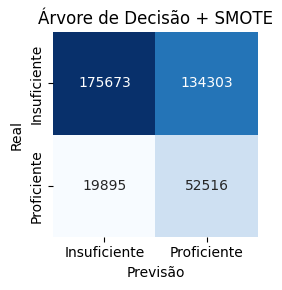

In [5]:
# Ajustando a variável resposta
df_2019['PROFICIENCIA_DESCRICAO'] = (
    df_2019['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Variável dependente
y = df_2019['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = pd.get_dummies(
    df_2019.drop(columns=['PROFICIENCIA_DESCRICAO']),
    drop_first=True
)

# Remove possíveis NaN de y
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

X = X.astype(float)
y = y.astype(int)

# Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Distribuição antes do SMOTE
print("Distribuição antes do SMOTE:")
print(y_train.value_counts())

# Aplicando SMOTE
smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nDistribuição após SMOTE:")
print(y_train_smote.value_counts())

# Árvore de Decisão
arvore = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

arvore.fit(
    X_train_smote,
    y_train_smote
)

# Previsões
y_pred = arvore.predict(X_test)

# Avaliação
print("\nAcurácia:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Insuficiente', 'Proficiente']
    )
)

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,3))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    xticklabels=['Insuficiente', 'Proficiente'],
    yticklabels=['Insuficiente', 'Proficiente']
)

plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Árvore de Decisão + SMOTE")
plt.tight_layout()
plt.show()

In [7]:
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': arvore.feature_importances_
})

importancias = importancias.sort_values(
    'Importancia',
    ascending=False
)

print(importancias.head(10))

                             Variavel  Importancia
26                     REPROVACAO_Sim     0.435374
14              QTD_COMPUTADOR_1 ou 2     0.135750
38           POS_EF_Somente trabalhar     0.075070
16       QTD_COMPUTADOR_Não respondeu     0.064290
15           QTD_COMPUTADOR_3 ou mais     0.052586
36                    POS_EF_Não sabe     0.050131
9                  ESCOL_MAE_Não sabe     0.032424
11  FREQUENCIA_CONVERSA_Não respondeu     0.019270
37             POS_EF_Somente estudar     0.017711
5                      COR_RACA_Preta     0.017216


#### 2021

Distribuição antes do SMOTE:
PROFICIENCIA_DESCRICAO
0    1268281
1     240662
Name: count, dtype: int64

Distribuição após SMOTE:
PROFICIENCIA_DESCRICAO
0    1268281
1    1268281
Name: count, dtype: int64

Acurácia:
0.6540786139180778

Classification Report:
              precision    recall  f1-score   support

Insuficiente       0.91      0.65      0.76    317071
 Proficiente       0.27      0.67      0.38     60165

    accuracy                           0.65    377236
   macro avg       0.59      0.66      0.57    377236
weighted avg       0.81      0.65      0.70    377236



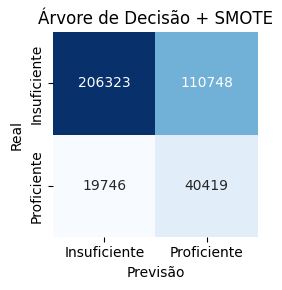

In [8]:
# Ajustando a variável resposta
df_2021['PROFICIENCIA_DESCRICAO'] = (
    df_2021['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Variável dependente
y = df_2021['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = pd.get_dummies(
    df_2021.drop(columns=['PROFICIENCIA_DESCRICAO']),
    drop_first=True
)

# Remove possíveis NaN de y
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

X = X.astype(float)
y = y.astype(int)

# Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Distribuição antes do SMOTE
print("Distribuição antes do SMOTE:")
print(y_train.value_counts())

# Aplicando SMOTE
smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nDistribuição após SMOTE:")
print(y_train_smote.value_counts())

# Árvore de Decisão
arvore = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

arvore.fit(
    X_train_smote,
    y_train_smote
)

# Previsões
y_pred = arvore.predict(X_test)

# Avaliação
print("\nAcurácia:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Insuficiente', 'Proficiente']
    )
)

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,3))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    xticklabels=['Insuficiente', 'Proficiente'],
    yticklabels=['Insuficiente', 'Proficiente']
)

plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Árvore de Decisão + SMOTE")
plt.tight_layout()
plt.show()

In [9]:
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': arvore.feature_importances_
})

importancias = importancias.sort_values(
    'Importancia',
    ascending=False
)

print(importancias.head(10))

                          Variavel  Importancia
29                  REPROVACAO_Sim     0.394129
17           QTD_COMPUTADOR_1 ou 2     0.130132
1                   SEXO_Masculino     0.099585
41        POS_EF_Somente trabalhar     0.070055
18        QTD_COMPUTADOR_3 ou mais     0.063953
12              ESCOL_MAE_Não sabe     0.040371
19    QTD_COMPUTADOR_Não respondeu     0.036181
39                 POS_EF_Não sabe     0.024860
8                   COR/RACA_Preta     0.017750
36  TEMPO_TRAB_DOMES_Não respondeu     0.016493


#### 2023

Distribuição antes do SMOTE:
PROFICIENCIA_DESCRICAO
0    1365796
1     276328
Name: count, dtype: int64

Distribuição após SMOTE:
PROFICIENCIA_DESCRICAO
1    1365796
0    1365796
Name: count, dtype: int64

Acurácia:
0.6595149708183528

Classification Report:
              precision    recall  f1-score   support

Insuficiente       0.90      0.67      0.76    341450
 Proficiente       0.28      0.63      0.38     69082

    accuracy                           0.66    410532
   macro avg       0.59      0.65      0.57    410532
weighted avg       0.79      0.66      0.70    410532



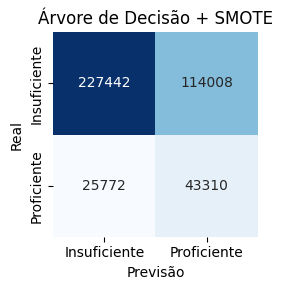

In [10]:
# Ajustando a variável resposta
df_2023['PROFICIENCIA_DESCRICAO'] = (
    df_2023['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Variável dependente
y = df_2023['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = pd.get_dummies(
    df_2023.drop(columns=['PROFICIENCIA_DESCRICAO']),
    drop_first=True
)

# Remove possíveis NaN de y
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

X = X.astype(float)
y = y.astype(int)

# Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Distribuição antes do SMOTE
print("Distribuição antes do SMOTE:")
print(y_train.value_counts())

# Aplicando SMOTE
smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nDistribuição após SMOTE:")
print(y_train_smote.value_counts())

# Árvore de Decisão
arvore = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

arvore.fit(
    X_train_smote,
    y_train_smote
)

# Previsões
y_pred = arvore.predict(X_test)

# Avaliação
print("\nAcurácia:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Insuficiente', 'Proficiente']
    )
)

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,3))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    xticklabels=['Insuficiente', 'Proficiente'],
    yticklabels=['Insuficiente', 'Proficiente']
)

plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Árvore de Decisão + SMOTE")
plt.tight_layout()
plt.show()

In [11]:
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': arvore.feature_importances_
})

importancias = importancias.sort_values(
    'Importancia',
    ascending=False
)

print(importancias.head(10))

                    Variavel  Importancia
29            REPROVACAO_Sim     0.365934
17     QTD_COMPUTADOR_1 ou 2     0.110881
1             SEXO_Masculino     0.104077
41  POS_EF_Somente trabalhar     0.075542
18  QTD_COMPUTADOR_3 ou mais     0.067049
38      POS_EF_Não respondeu     0.057339
39           POS_EF_Não sabe     0.043570
12        ESCOL_MAE_Não sabe     0.036599
8             COR/RACA_Preta     0.022840
10  ESCOL_MAE_Médio completo     0.015940


#### XGBoost
Enquanto uma árvore de decisão cria uma única árvore, o XGBoost cria muitas árvores sequencialmente. A previsão final é a combinação de todas as árvores.

#### 2019

Classe 0: 1239902
Classe 1: 289642
scale_pos_weight: 4.28

Acurácia:
0.6345

Classification Report:
              precision    recall  f1-score   support

Insuficiente       0.90      0.62      0.73    309976
 Proficiente       0.30      0.71      0.42     72411

    accuracy                           0.63    382387
   macro avg       0.60      0.66      0.58    382387
weighted avg       0.79      0.63      0.67    382387



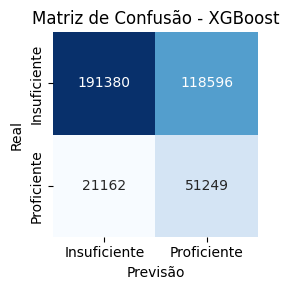

In [15]:
# Tratamento da variável resposta
df_2019['PROFICIENCIA_DESCRICAO'] = (
    df_2019['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Variável dependente
y = df_2019['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = pd.get_dummies(
    df_2019.drop(columns=['PROFICIENCIA_DESCRICAO']),
    drop_first=True
)

# Remove registros inválidos
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

# Converte para numérico
X = X.astype(float)
y = y.astype(int)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Peso para balanceamento
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

scale_pos_weight = n_neg / n_pos

print(f"Classe 0: {n_neg}")
print(f"Classe 1: {n_pos}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Modelo XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# Treinamento
xgb.fit(X_train, y_train)

# Previsões
y_pred = xgb.predict(X_test)

# Avaliação
print("\nAcurácia:")
print(f"{accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Insuficiente', 'Proficiente']
    )
)
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,3))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    xticklabels=['Insuficiente', 'Proficiente'],
    yticklabels=['Insuficiente', 'Proficiente']
)

plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão - XGBoost")
plt.tight_layout()
plt.show()

# Importância das Variáveis
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': xgb.feature_importances_
})

importancias = importancias.sort_values(
    'Importancia',
    ascending=False
)

print("\nTop 10 variáveis mais importantes:")
print(importancias.head(10))

#### 2021

Classe 0: 1268281
Classe 1: 240662
scale_pos_weight: 5.27

Acurácia:
0.6563

Classification Report:
              precision    recall  f1-score   support

Insuficiente       0.92      0.64      0.76    317071
 Proficiente       0.28      0.72      0.40     60165

    accuracy                           0.66    377236
   macro avg       0.60      0.68      0.58    377236
weighted avg       0.82      0.66      0.70    377236



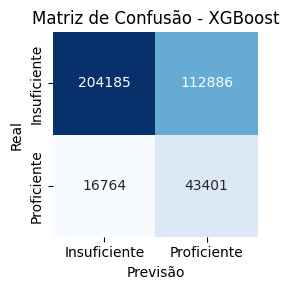


Top 10 variáveis mais importantes:
                       Variavel  Importancia
29               REPROVACAO_Sim     0.313706
17        QTD_COMPUTADOR_1 ou 2     0.074923
20             QTD_CARRO_1 ou 2     0.044902
1                SEXO_Masculino     0.044620
41     POS_EF_Somente trabalhar     0.044085
18     QTD_COMPUTADOR_3 ou mais     0.043830
12           ESCOL_MAE_Não sabe     0.042683
8                COR/RACA_Preta     0.030959
13  ESCOL_MAE_Superior completo     0.029066
10     ESCOL_MAE_Médio completo     0.027664


In [17]:
# Tratamento da variável resposta
df_2021['PROFICIENCIA_DESCRICAO'] = (
    df_2021['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Variável dependente
y = df_2021['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = pd.get_dummies(
    df_2021.drop(columns=['PROFICIENCIA_DESCRICAO']),
    drop_first=True
)

# Remove registros inválidos
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

# Converte para numérico
X = X.astype(float)
y = y.astype(int)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Peso para balanceamento
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

scale_pos_weight = n_neg / n_pos

print(f"Classe 0: {n_neg}")
print(f"Classe 1: {n_pos}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Modelo XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# Treinamento
xgb.fit(X_train, y_train)

# Previsões
y_pred = xgb.predict(X_test)

# Avaliação
print("\nAcurácia:")
print(f"{accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Insuficiente', 'Proficiente']
    )
)
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,3))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    xticklabels=['Insuficiente', 'Proficiente'],
    yticklabels=['Insuficiente', 'Proficiente']
)

plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão - XGBoost")
plt.tight_layout()
plt.show()

# Importância das Variáveis
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': xgb.feature_importances_
})

importancias = importancias.sort_values(
    'Importancia',
    ascending=False
)

print("\nTop 10 variáveis mais importantes:")
print(importancias.head(10))

#### 2023

Classe 0: 1365796
Classe 1: 276328
scale_pos_weight: 4.94

Acurácia:
0.6515

Classification Report:
              precision    recall  f1-score   support

Insuficiente       0.91      0.64      0.75    341450
 Proficiente       0.28      0.70      0.40     69082

    accuracy                           0.65    410532
   macro avg       0.60      0.67      0.58    410532
weighted avg       0.81      0.65      0.69    410532



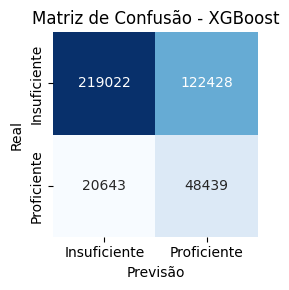


Top 10 variáveis mais importantes:
                       Variavel  Importancia
29               REPROVACAO_Sim     0.273848
17        QTD_COMPUTADOR_1 ou 2     0.067081
41     POS_EF_Somente trabalhar     0.057238
20             QTD_CARRO_1 ou 2     0.047851
13  ESCOL_MAE_Superior completo     0.044063
1                SEXO_Masculino     0.043245
10     ESCOL_MAE_Médio completo     0.042532
18     QTD_COMPUTADOR_3 ou mais     0.041482
12           ESCOL_MAE_Não sabe     0.039642
8                COR/RACA_Preta     0.036699


In [18]:
# Tratamento da variável resposta
df_2023['PROFICIENCIA_DESCRICAO'] = (
    df_2023['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Variável dependente
y = df_2023['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = pd.get_dummies(
    df_2023.drop(columns=['PROFICIENCIA_DESCRICAO']),
    drop_first=True
)

# Remove registros inválidos
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

# Converte para numérico
X = X.astype(float)
y = y.astype(int)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Peso para balanceamento
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

scale_pos_weight = n_neg / n_pos

print(f"Classe 0: {n_neg}")
print(f"Classe 1: {n_pos}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Modelo XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# Treinamento
xgb.fit(X_train, y_train)

# Previsões
y_pred = xgb.predict(X_test)

# Avaliação
print("\nAcurácia:")
print(f"{accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Insuficiente', 'Proficiente']
    )
)
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,3))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    xticklabels=['Insuficiente', 'Proficiente'],
    yticklabels=['Insuficiente', 'Proficiente']
)

plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão - XGBoost")
plt.tight_layout()
plt.show()

# Importância das Variáveis
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': xgb.feature_importances_
})

importancias = importancias.sort_values(
    'Importancia',
    ascending=False
)

print("\nTop 10 variáveis mais importantes:")
print(importancias.head(10))